In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('Rent_cleaned_data.csv')

In [3]:
df_copy=df

In [4]:
df_copy.head()

,locality,city,area,beds,bathrooms,balconies,furnishing,rent,property_type
0,Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,120000.0,Flat
1,Powai,Mumbai,490.0,1,1,0,Semi-Furnished,40000.0,Flat
2,other,Pune,550.0,1,1,0,Unfurnished,12000.0,House
3,other,Nagpur,1000.0,2,2,0,Unfurnished,8000.0,Flat
4,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,15000.0,Flat


### Train-Test Data Split

#### Extracting Independent (input) & Dependent (output) features

In [5]:
X=df_copy.drop('rent',axis=1)
y=df['rent']

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train

,locality,city,area,beds,bathrooms,balconies,furnishing,property_type
4660,other,Bangalore,3300.0,4,4,3,Furnished,Flat
4410,other,Mumbai,650.0,2,2,0,Semi-Furnished,Flat
501,Bandra West,Mumbai,2100.0,4,3,4,Semi-Furnished,Flat
2432,other,Mumbai,400.0,1,2,0,Unfurnished,Flat
6922,other,Bangalore,450.0,1,1,0,Semi-Furnished,House
...,...,...,...,...,...,...,...,...
5226,Lohegaon,Pune,760.0,2,2,0,Furnished,Flat
5390,other,Bangalore,1740.0,3,3,0,Furnished,Flat
860,Malad East,Mumbai,719.0,2,2,2,Unfurnished,Flat
7603,Sarjapur Road,Bangalore,800.0,2,2,0,Semi-Furnished,Flat


In [22]:
df['locality'].nunique()

51

#### Checking for Multicollinearity

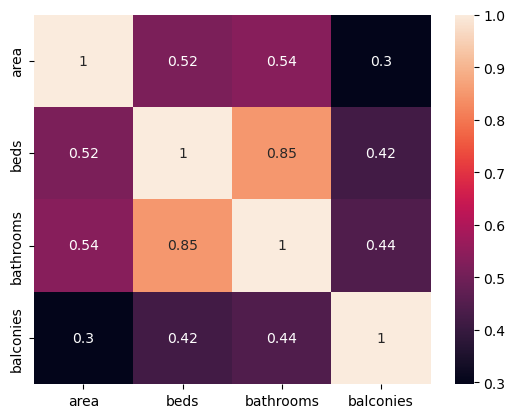

In [13]:
corr=df[['area','beds','bathrooms','balconies']].corr()
sns.heatmap(corr,annot=True)
plt.show()

#### Observation:
- There is no such strong Multicollinearity present in the Dataset

### Performing One Hot Encoding for Categorical Columns & Standard Scaling for Numerical Columns

In [14]:
Categorical_col=df_copy.select_dtypes(include='object')
Numerical_col=df_copy.select_dtypes(include='number')

In [15]:
categories=Categorical_col.columns.to_list()
numerics=Numerical_col.drop('rent',axis=1).columns.to_list()

In [18]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(transformers=[('num',StandardScaler(),numerics),('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),categories)])


In [19]:
X_train_processed=preprocessor.fit_transform(X_train)
X_test_proccessed=preprocessor.transform(X_test)

### Model Training & Choosing
- Linear Regression
- Lasso Regression & LassoCV
- Ridge Regression & RidgeCV

### Linear Regression

Mean Absolute Error:  29475.089170628366
R2 Score:  0.5583772820701942


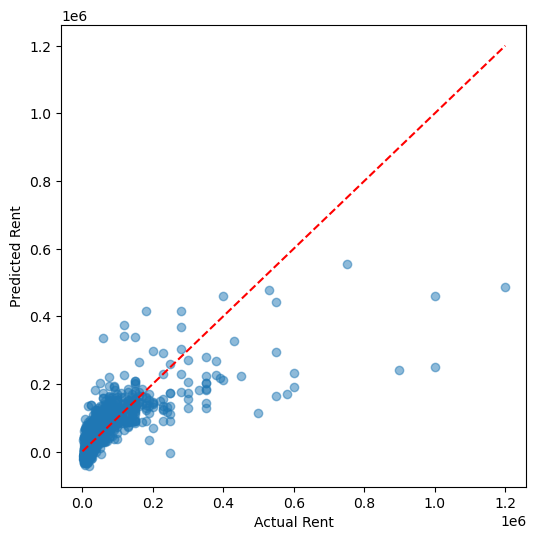

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

linreg=LinearRegression()
linreg.fit(X_train_processed,y_train)
y_pred=linreg.predict(X_test_proccessed)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("R2 Score: ",score)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()


### Lasso & LassoCV Regression

Mean Absolute Error:  29474.473040500707
R2 Score:  0.558357318236245


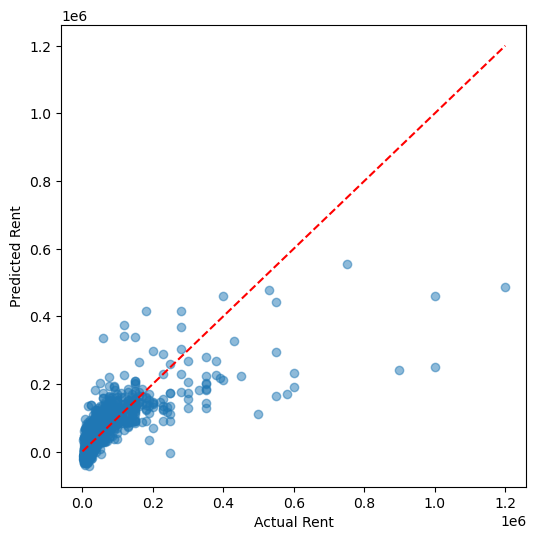

In [24]:
from sklearn.linear_model import Lasso


laso=Lasso()
laso.fit(X_train_processed,y_train)
y_pred=laso.predict(X_test_proccessed)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("R2 Score: ",score)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()

Mean Absolute Error:  29444.005183152512
R2 Score:  0.5582389162733479


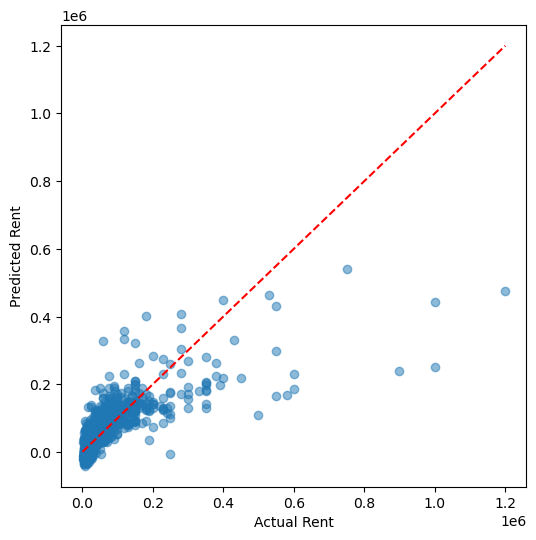

In [25]:
from sklearn.linear_model import LassoCV


lasocv=LassoCV(cv=5,random_state=42)
lasocv.fit(X_train_processed,y_train)
y_pred=lasocv.predict(X_test_proccessed)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("R2 Score: ",score)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()

### Ridge & RidgeCV Regression

Mean Absolute Error:  29537.57130490567
R2 Score:  0.5578593505677214


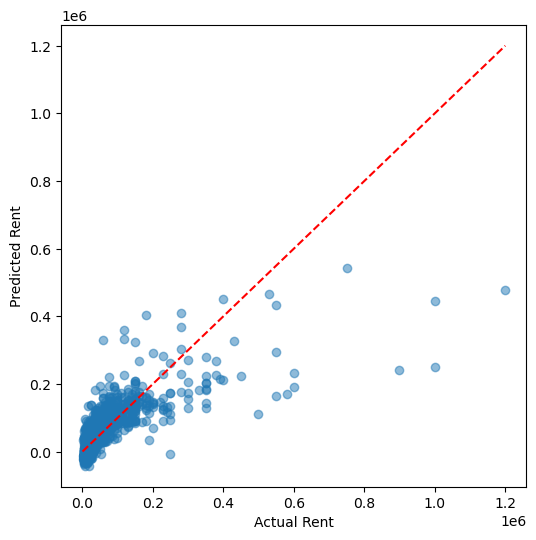

In [26]:
from sklearn.linear_model import Ridge


ridge=Ridge()
ridge.fit(X_train_processed,y_train)
y_pred=ridge.predict(X_test_proccessed)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("R2 Score: ",score)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()

Mean Absolute Error:  29800.16255595553
R2 Score:  0.550404989942185


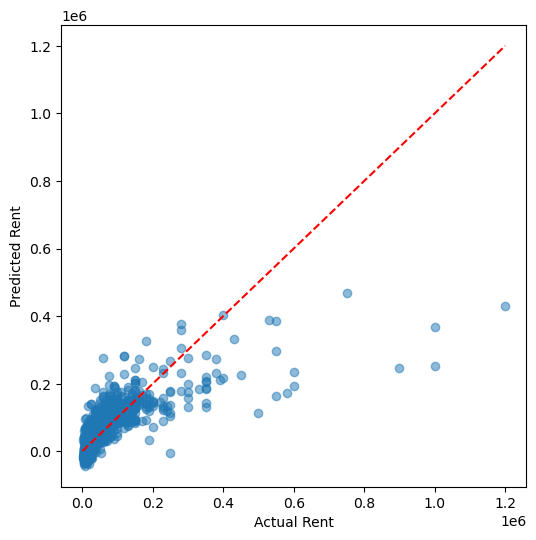

In [28]:
from sklearn.linear_model import RidgeCV


ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_processed,y_train)
y_pred=ridgecv.predict(X_test_proccessed)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean Absolute Error: ",mae)
print("R2 Score: ",score)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()

### Polynomial & Polynomial-Ridge Regression

0.6883475507208102
22523.238446389867


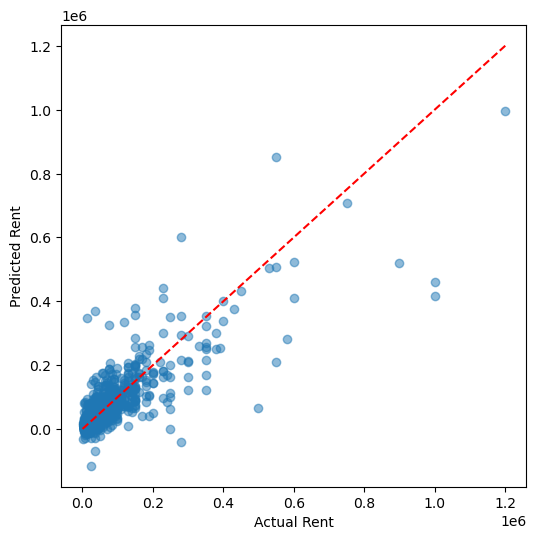

In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

poly_model.fit(X_train_processed, y_train)

y_pred = poly_model.predict(X_test_proccessed)

print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()

In [33]:
print(poly_model.score(X_train_processed, y_train))
print(poly_model.score(X_test_proccessed, y_test))

0.8002962776376992
0.6883475507208102


0.6853111944281327
21936.177204343232


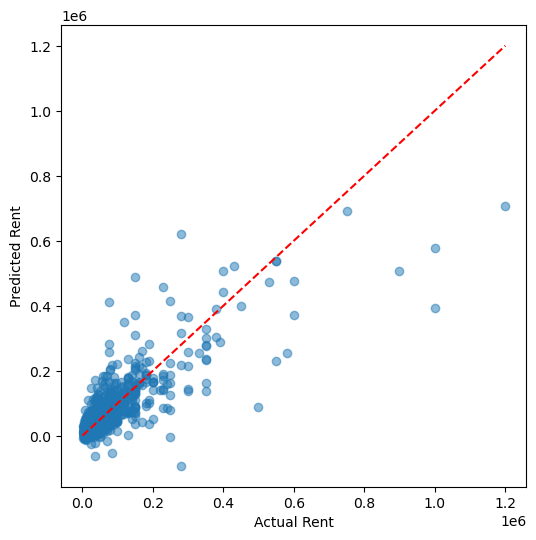

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV

poly_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', RidgeCV(alphas=[0.01,0.1,1,10,100]))
])

poly_ridge.fit(X_train_processed, y_train)

y_pred = poly_ridge.predict(X_test_proccessed)

print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()

0.6883475507208102
22523.238446389867


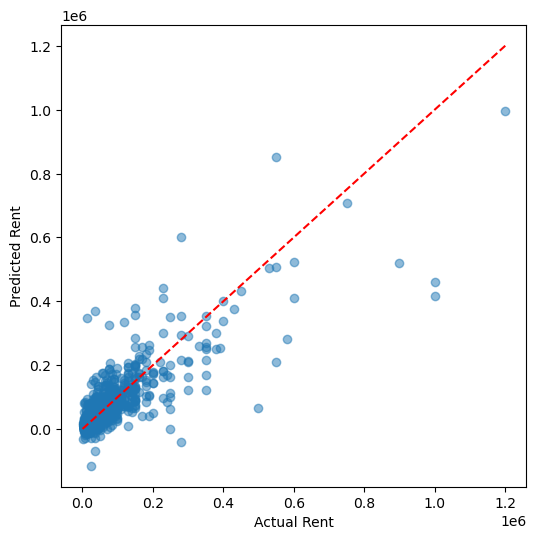

In [37]:
## Making a single pipeline
full_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('poly',PolynomialFeatures(degree=2,include_bias=False)),
    ('lr',LinearRegression())
])

full_pipeline.fit(X_train,y_train)
y_pred=full_pipeline.predict(X_test)

print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()

### Observation & Conclusion
- The input and output features don't follow a Linear Relationship.
- Compared to Linear Regression Models, Polynomial Regression Model gave better results.

### Model & Scaler Pickling

In [35]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [36]:
poly_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [38]:
import pickle
pickle.dump(full_pipeline,open('Rent_predictor.pkl','wb'))
